# Customer Segmentation and Sales Analytics using K-Means Clustering

**IBM SkillsBuild Data Analytics with AI Internship**

---

## Project Overview

This notebook performs end-to-end customer segmentation on a retail sales dataset.  
The workflow covers data loading, cleaning, exploratory data analysis (EDA), feature engineering,  
K-Means clustering, visualisation, and business insight generation.

**Sections:**
1. Import Libraries
2. Load Dataset
3. Data Quality Check
4. Data Cleaning
5. Exploratory Data Analysis (EDA)
6. Customer Purchasing Behaviour Analysis (RFM)
7. Feature Preparation
8. K-Means Clustering & Elbow Method
9. Cluster Visualisation
10. Cluster Interpretation
11. Business Insights & Recommendations
12. Conclusion


---
## Section 1 — Import Libraries

In [1]:
# Standard library
import warnings
import os

# Data manipulation
import pandas as pd
import numpy as np

# Excel file handling
import openpyxl

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Machine learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Settings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# Ensure output directory exists
os.makedirs('outputs', exist_ok=True)

print('All libraries imported successfully.')
print(f'pandas    : {pd.__version__}')
print(f'numpy     : {np.__version__}')
print(f'openpyxl  : {openpyxl.__version__}')

import sklearn
print(f'sklearn   : {sklearn.__version__}')

All libraries imported successfully.
pandas    : 2.2.3
numpy     : 2.1.3
openpyxl  : 3.1.5
sklearn   : 1.6.1


---
## Section 2 — Load Dataset

> **Dataset source:** UCI Machine Learning Repository — Online Retail dataset.
>
> The notebook automatically downloads and extracts the dataset when it is not already available in the Colab runtime. No manual dataset upload is required.

In [2]:
# ── Section 2: Load Dataset ────────────────────────────────────────────────

import os
import zipfile
import urllib.request
import pandas as pd

# Create data folder automatically
os.makedirs('data', exist_ok=True)

# Official UCI Online Retail dataset
ZIP_URL = 'https://archive.ics.uci.edu/static/public/352/online+retail.zip'
ZIP_FILE = 'data/online_retail.zip'
EXTRACT_FOLDER = 'data/uci_dataset'
EXCEL_FILE = 'data/uci_dataset/Online Retail.xlsx'

# Download dataset if it is not already available
if not os.path.exists(EXCEL_FILE):
    print('Downloading Online Retail dataset from UCI...')
    urllib.request.urlretrieve(ZIP_URL, ZIP_FILE)

    print('Extracting dataset...')
    os.makedirs(EXTRACT_FOLDER, exist_ok=True)

    with zipfile.ZipFile(ZIP_FILE, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_FOLDER)

    print('Dataset downloaded and extracted successfully.')

# Load the Excel dataset
df = pd.read_excel(EXCEL_FILE)

print(f'Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print('\nColumn names:')
print(df.columns.tolist())

print('\nFirst 5 rows:')
df.head()

Extracting dataset...
Dataset downloaded and extracted successfully.
Dataset loaded: 541,909 rows × 8 columns

Column names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

First 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


---
## Section 3 — Data Quality Check

Before cleaning, we inspect the dataset for:
- Shape and data types
- Missing values
- Duplicate rows
- Basic descriptive statistics

In [3]:
print('=== Shape ===')
print(f'{df.shape[0]:,} rows, {df.shape[1]} columns')

print('\n=== Data Types ===')
print(df.dtypes)

=== Shape ===
541,909 rows, 8 columns

=== Data Types ===
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object


In [4]:
print('=== Missing Values ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(missing_df if not missing_df.empty else 'No missing values found.')

=== Missing Values ===
             Missing Count  Missing %
CustomerID          135080      24.93
Description           1454       0.27


In [5]:
print('=== Duplicate Rows ===')
dup_count = df.duplicated().sum()
print(f'{dup_count:,} duplicate rows found ({dup_count / len(df) * 100:.2f}%)')

print('\n=== Descriptive Statistics ===')
df.describe()

=== Duplicate Rows ===
5,268 duplicate rows found (0.97%)

=== Descriptive Statistics ===


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


---
## Section 4 — Data Cleaning

Based on the quality check above, we will:
1. Drop duplicate rows
2. Handle missing values (drop or impute as appropriate)
3. Fix data types (parse dates, ensure numeric types)
4. Remove records with invalid quantities or prices (negative / zero values)
5. Create a `TotalPrice` column (`Quantity × UnitPrice`)

> **Note:** Column name mapping below. Update the dictionary if your dataset uses different names.

In [6]:
# ── Column name mapping ─────────────────────────────────────────────────────────
# Update these keys to match your actual column names
COL_CUSTOMER_ID  = 'CustomerID'    # Unique customer identifier
COL_INVOICE_DATE = 'InvoiceDate'   # Transaction date
COL_QUANTITY     = 'Quantity'      # Units purchased
COL_UNIT_PRICE   = 'UnitPrice'     # Price per unit
COL_INVOICE_NO   = 'InvoiceNo'     # Invoice / order identifier
COL_DESCRIPTION  = 'Description'   # Product description
# ───────────────────────────────────────────────────────────────────────────────

df_clean = df.copy()

# Step 1 — Drop duplicates
before = len(df_clean)
df_clean.drop_duplicates(inplace=True)
print(f'Duplicates removed : {before - len(df_clean):,} rows')

# Step 2 — Drop rows with missing CustomerID (cannot segment without it)
before = len(df_clean)
df_clean.dropna(subset=[COL_CUSTOMER_ID], inplace=True)
print(f'Rows without CustomerID removed : {before - len(df_clean):,} rows')

# Step 3 — Parse invoice date
df_clean[COL_INVOICE_DATE] = pd.to_datetime(
    df_clean[COL_INVOICE_DATE],
    dayfirst=True,
    errors='coerce'
)
df_clean.dropna(subset=[COL_INVOICE_DATE], inplace=True)
print(f'Date column parsed. Remaining rows : {len(df_clean):,}')

Duplicates removed : 5,268 rows
Rows without CustomerID removed : 135,037 rows
Date column parsed. Remaining rows : 401,604


In [7]:
# Step 4 — Remove returns (negative quantity) and invalid prices
before = len(df_clean)
df_clean = df_clean[(df_clean[COL_QUANTITY] > 0) & (df_clean[COL_UNIT_PRICE] > 0)]
print(f'Invalid quantity/price rows removed : {before - len(df_clean):,} rows')

# Step 5 — Create TotalPrice column
df_clean['TotalPrice'] = df_clean[COL_QUANTITY] * df_clean[COL_UNIT_PRICE]

print(f'\nClean dataset shape : {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns')
df_clean.head()

Invalid quantity/price rows removed : 8,912 rows

Clean dataset shape : 392,692 rows × 9 columns


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


---
## Section 5 — Exploratory Data Analysis (EDA)

We explore the cleaned data to understand:
- Distribution of order quantities and transaction values
- Sales trend over time
- Top products by revenue
- Correlation between numeric features

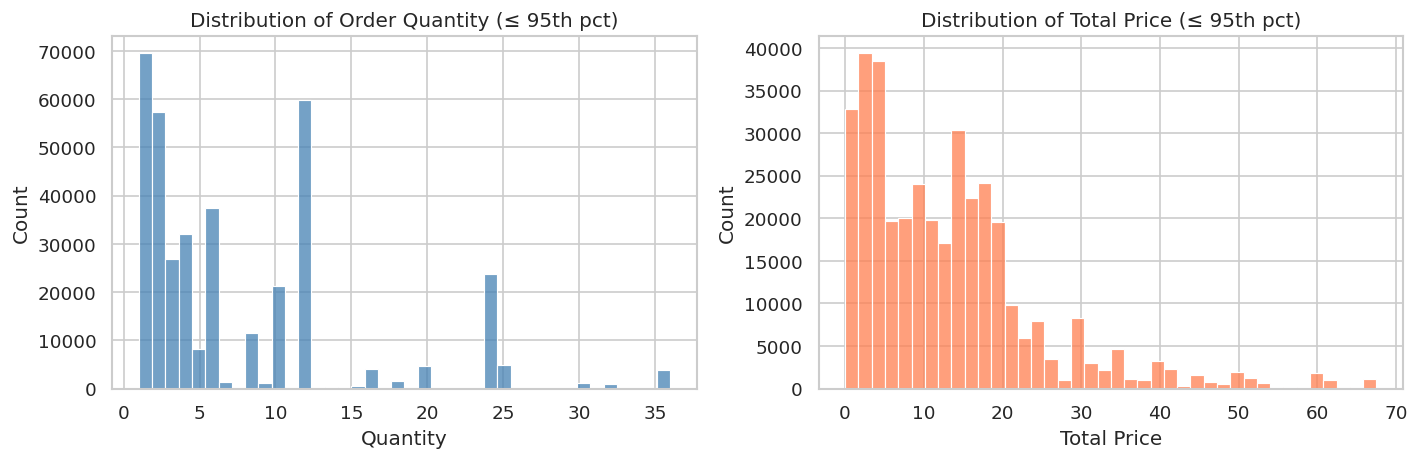

Saved → outputs/eda_distributions.png


In [8]:
# --- Distribution of Quantity and TotalPrice ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Cap at 95th percentile for readability
q95_qty   = df_clean[COL_QUANTITY].quantile(0.95)
q95_price = df_clean['TotalPrice'].quantile(0.95)

sns.histplot(df_clean[df_clean[COL_QUANTITY] <= q95_qty][COL_QUANTITY],
             bins=40, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Order Quantity (≤ 95th pct)')
axes[0].set_xlabel('Quantity')

sns.histplot(df_clean[df_clean['TotalPrice'] <= q95_price]['TotalPrice'],
             bins=40, ax=axes[1], color='coral')
axes[1].set_title('Distribution of Total Price (≤ 95th pct)')
axes[1].set_xlabel('Total Price')

plt.tight_layout()
plt.savefig('outputs/eda_distributions.png', bbox_inches='tight')
plt.show()
print('Saved → outputs/eda_distributions.png')

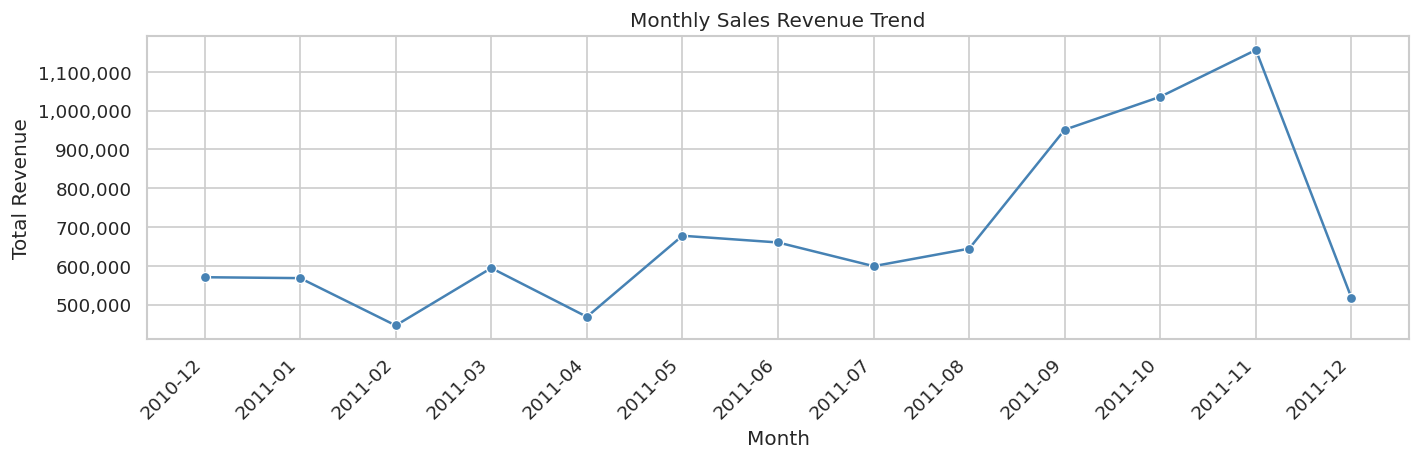

Saved → outputs/eda_monthly_sales.png


In [9]:
# --- Monthly Sales Trend ---
df_clean['YearMonth'] = df_clean[COL_INVOICE_DATE].dt.to_period('M')
monthly_sales = df_clean.groupby('YearMonth')['TotalPrice'].sum().reset_index()
monthly_sales['YearMonth'] = monthly_sales['YearMonth'].astype(str)

plt.figure(figsize=(12, 4))
sns.lineplot(data=monthly_sales, x='YearMonth', y='TotalPrice', marker='o', color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.title('Monthly Sales Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig('outputs/eda_monthly_sales.png', bbox_inches='tight')
plt.show()
print('Saved → outputs/eda_monthly_sales.png')

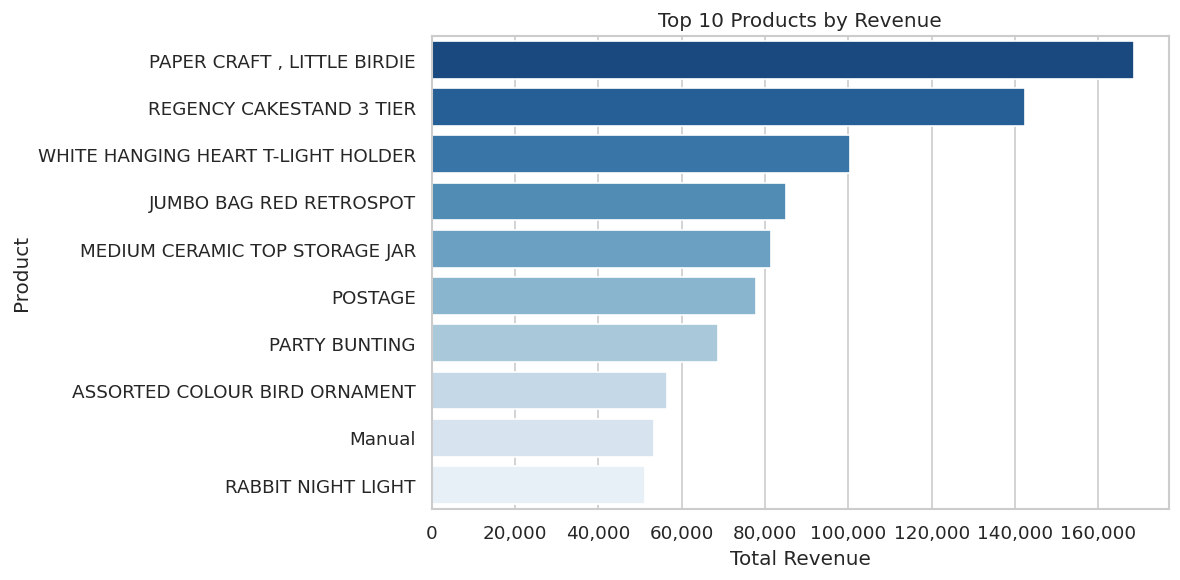

Saved → outputs/eda_top_products.png


In [10]:
# --- Top 10 Products by Revenue ---
top_products = (
    df_clean.groupby(COL_DESCRIPTION)['TotalPrice']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_products, x='TotalPrice', y=COL_DESCRIPTION, palette='Blues_r')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Product')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig('outputs/eda_top_products.png', bbox_inches='tight')
plt.show()
print('Saved → outputs/eda_top_products.png')

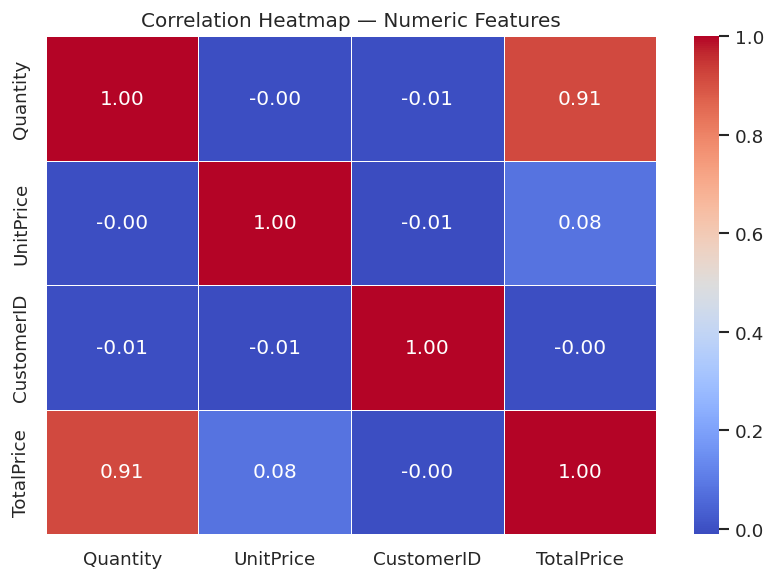

Saved → outputs/eda_correlation.png


In [11]:
# --- Correlation Heatmap ---
numeric_cols = df_clean.select_dtypes(include='number')

plt.figure(figsize=(7, 5))
sns.heatmap(numeric_cols.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.savefig('outputs/eda_correlation.png', bbox_inches='tight')
plt.show()
print('Saved → outputs/eda_correlation.png')

---
## Section 6 — Customer Purchasing Behaviour Analysis (RFM)

We build **RFM features** — a widely used framework in customer analytics:

| Feature | Definition |
|---|---|
| **Recency (R)** | Days since the customer's last purchase (lower = more recent) |
| **Frequency (F)** | Total number of invoices / transactions made |
| **Monetary (M)** | Total amount spent across all transactions |

In [12]:
# Reference date: one day after the last transaction in the dataset
reference_date = df_clean[COL_INVOICE_DATE].max() + pd.Timedelta(days=1)
print(f'Reference date for Recency calculation: {reference_date.date()}')

rfm = df_clean.groupby(COL_CUSTOMER_ID).agg(
    Recency   = (COL_INVOICE_DATE, lambda x: (reference_date - x.max()).days),
    Frequency = (COL_INVOICE_NO,   'nunique'),
    Monetary  = ('TotalPrice',     'sum')
).reset_index()

rfm.columns = [COL_CUSTOMER_ID, 'Recency', 'Frequency', 'Monetary']
print(f'\nRFM table shape: {rfm.shape}')
rfm.head(10)

Reference date for Recency calculation: 2011-12-10

RFM table shape: (4338, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40
5,12352.0,36,8,2506.04
6,12353.0,204,1,89.00
7,12354.0,232,1,1079.40
8,12355.0,214,1,459.40
9,12356.0,23,3,2811.43


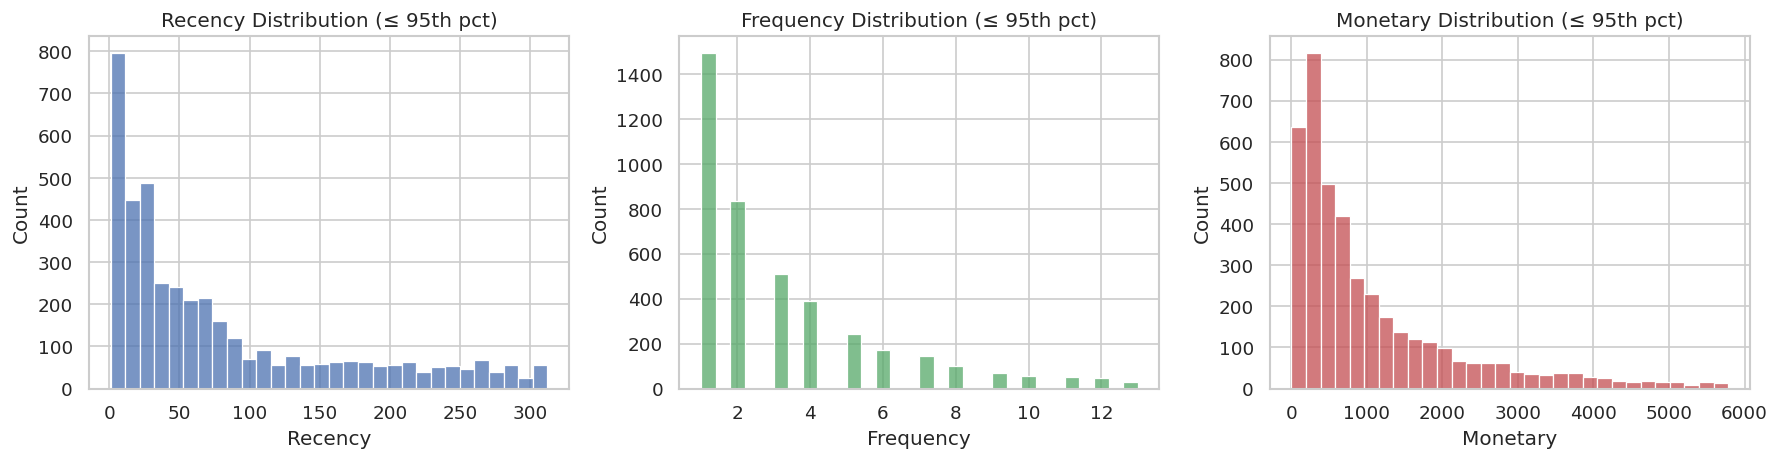

Saved → outputs/eda_rfm_distributions.png


In [13]:
# --- RFM Distributions ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
rfm_cols   = ['Recency', 'Frequency', 'Monetary']
colors     = ['#4C72B0', '#55A868', '#C44E52']

for ax, col, color in zip(axes, rfm_cols, colors):
    # Cap Monetary at 95th pct for readability
    plot_data = rfm[rfm[col] <= rfm[col].quantile(0.95)][col]
    sns.histplot(plot_data, bins=30, ax=ax, color=color)
    ax.set_title(f'{col} Distribution (≤ 95th pct)')
    ax.set_xlabel(col)

plt.tight_layout()
plt.savefig('outputs/eda_rfm_distributions.png', bbox_inches='tight')
plt.show()
print('Saved → outputs/eda_rfm_distributions.png')

In [14]:
# --- Summary statistics for RFM ---
print('RFM Summary Statistics:')
rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2)

RFM Summary Statistics:


,Recency,Frequency,Monetary
count,4338.00,4338.00,4338.00
mean,92.54,4.27,2048.69
std,100.01,7.70,8985.23
min,1.00,1.00,3.75
25%,18.00,1.00,306.48
50%,51.00,2.00,668.57
75%,142.00,5.00,1660.60
max,374.00,209.00,280206.02


---
## Section 7 — Feature Preparation

K-Means is a distance-based algorithm; features on different scales will bias the clustering.  
We apply **StandardScaler** (zero mean, unit variance) to the RFM features before fitting.

In [15]:
features = ['Recency', 'Frequency', 'Monetary']
X = rfm[features].copy()

scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

print('Feature scaling complete (StandardScaler).')
print('\nScaled feature summary:')
X_scaled_df.describe().round(3)

Feature scaling complete (StandardScaler).

Scaled feature summary:


,Recency,Frequency,Monetary
count,4338.000,4338.000,4338.000
mean,0.000,0.000,0.000
std,1.000,1.000,1.000
min,-0.915,-0.425,-0.228
25%,-0.745,-0.425,-0.194
50%,-0.415,-0.295,-0.154
75%,0.495,0.095,-0.043
max,2.815,26.598,30.961


---
## Section 8 — K-Means Clustering & Elbow Method

### 8.1 Elbow Method
We fit K-Means for **k = 1 to 10** and plot the **inertia** (within-cluster sum of squares).  
The optimal k is the point where adding another cluster gives diminishing returns — the "elbow".

### 8.2 Silhouette Score
We also compute the Silhouette Score for each k to confirm the choice quantitatively.

In [16]:
K_RANGE = range(1, 11)
inertias        = []
silhouette_scores = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    if k > 1:  # Silhouette requires at least 2 clusters
        score = silhouette_score(X_scaled, km.labels_)
        silhouette_scores.append(score)
    else:
        silhouette_scores.append(None)

print('Inertia values:')
for k, inertia in zip(K_RANGE, inertias):
    print(f'  k={k:2d}  inertia={inertia:,.2f}')

Inertia values:
  k= 1  inertia=13,014.00
  k= 2  inertia=9,014.57
  k= 3  inertia=5,441.32
  k= 4  inertia=4,096.30
  k= 5  inertia=3,119.79
  k= 6  inertia=2,473.79
  k= 7  inertia=2,023.59
  k= 8  inertia=1,717.01
  k= 9  inertia=1,468.79
  k=10  inertia=1,281.05


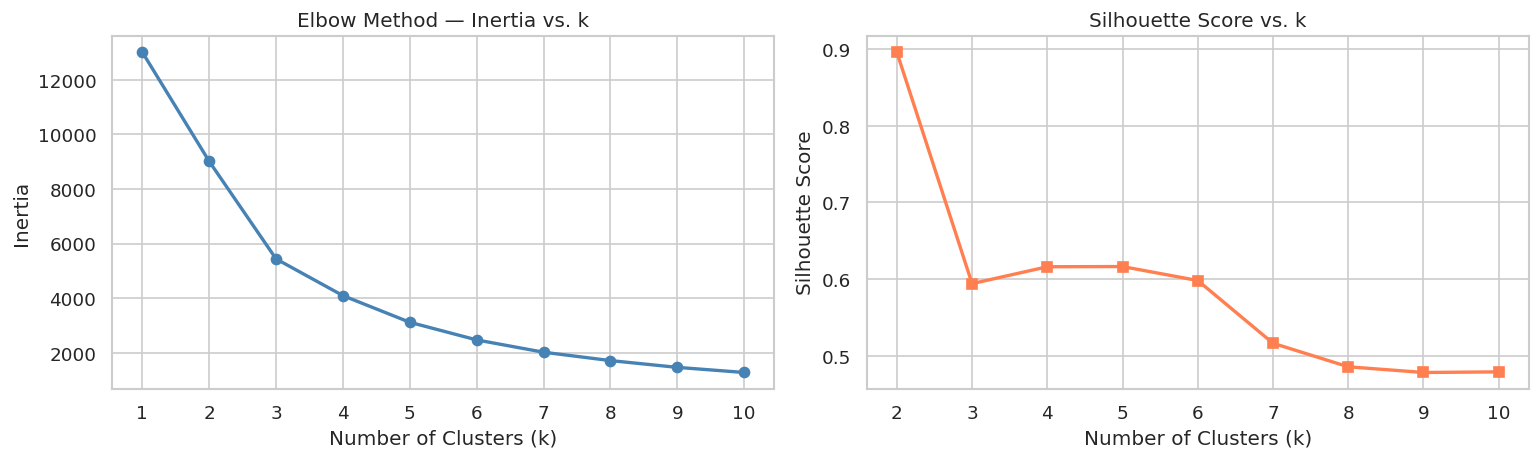

Saved → outputs/elbow_curve.png


In [17]:
# --- Elbow Curve ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Inertia
axes[0].plot(list(K_RANGE), inertias, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Elbow Method — Inertia vs. k')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(list(K_RANGE))

# Silhouette Score
sil_k      = list(K_RANGE)[1:]          # starts at k=2
sil_scores = [s for s in silhouette_scores if s is not None]
axes[1].plot(sil_k, sil_scores, marker='s', color='coral', linewidth=2)
axes[1].set_title('Silhouette Score vs. k')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(sil_k)

plt.tight_layout()
plt.savefig('outputs/elbow_curve.png', bbox_inches='tight')
plt.show()
print('Saved → outputs/elbow_curve.png')

In [18]:
# ── Set optimal k after reviewing the plots above ──────────────────────────────
OPTIMAL_K = 4    # <-- UPDATE based on the elbow / silhouette charts
# ───────────────────────────────────────────────────────────────────────────────

kmeans_final = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=10, random_state=42)
kmeans_final.fit(X_scaled)

rfm['Cluster'] = kmeans_final.labels_

print(f'K-Means fitted with k = {OPTIMAL_K}')
print(f'Final inertia : {kmeans_final.inertia_:,.2f}')
print(f'Silhouette Score : {silhouette_score(X_scaled, kmeans_final.labels_):.4f}')
print('\nCluster counts:')
print(rfm['Cluster'].value_counts().sort_index())

K-Means fitted with k = 4
Final inertia : 4,096.30
Silhouette Score : 0.6162

Cluster counts:
Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64


---
## Section 9 — Cluster Visualisation

Since the RFM feature space is 3-dimensional, we use **PCA** to reduce it to 2 dimensions  
solely for visualisation purposes. The clustering itself was performed in the full 3-D space.

In [19]:
# --- PCA Reduction for visualisation only ---
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = rfm['Cluster'].values

print(f'Explained variance ratio: PC1={pca.explained_variance_ratio_[0]:.2%},',
      f'PC2={pca.explained_variance_ratio_[1]:.2%}')
print(f'Total variance explained by 2 components: {sum(pca.explained_variance_ratio_):.2%}')

Explained variance ratio: PC1=55.47%, PC2=30.25%
Total variance explained by 2 components: 85.73%


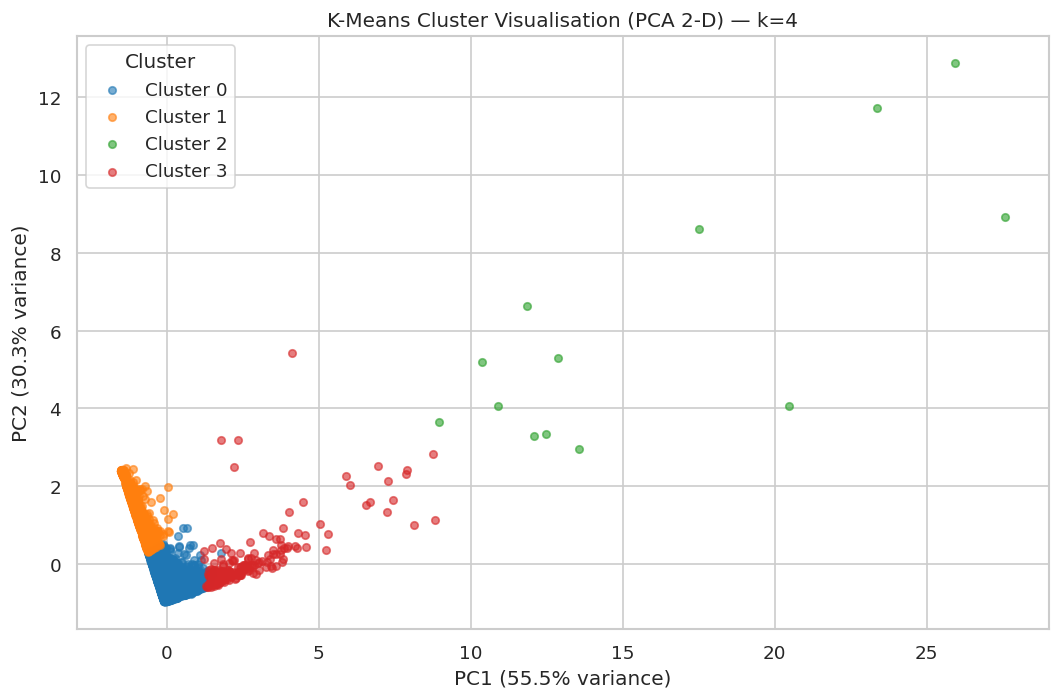

Saved → outputs/cluster_scatter.png


In [20]:
# --- Scatter Plot: Clusters in PCA space ---
palette = sns.color_palette('tab10', n_colors=OPTIMAL_K)

plt.figure(figsize=(9, 6))
for cluster_id in sorted(pca_df['Cluster'].unique()):
    subset = pca_df[pca_df['Cluster'] == cluster_id]
    plt.scatter(subset['PC1'], subset['PC2'],
                label=f'Cluster {cluster_id}',
                alpha=0.6, s=20, color=palette[cluster_id])

plt.title(f'K-Means Cluster Visualisation (PCA 2-D) — k={OPTIMAL_K}')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.legend(title='Cluster', loc='best')
plt.tight_layout()
plt.savefig('outputs/cluster_scatter.png', bbox_inches='tight')
plt.show()
print('Saved → outputs/cluster_scatter.png')

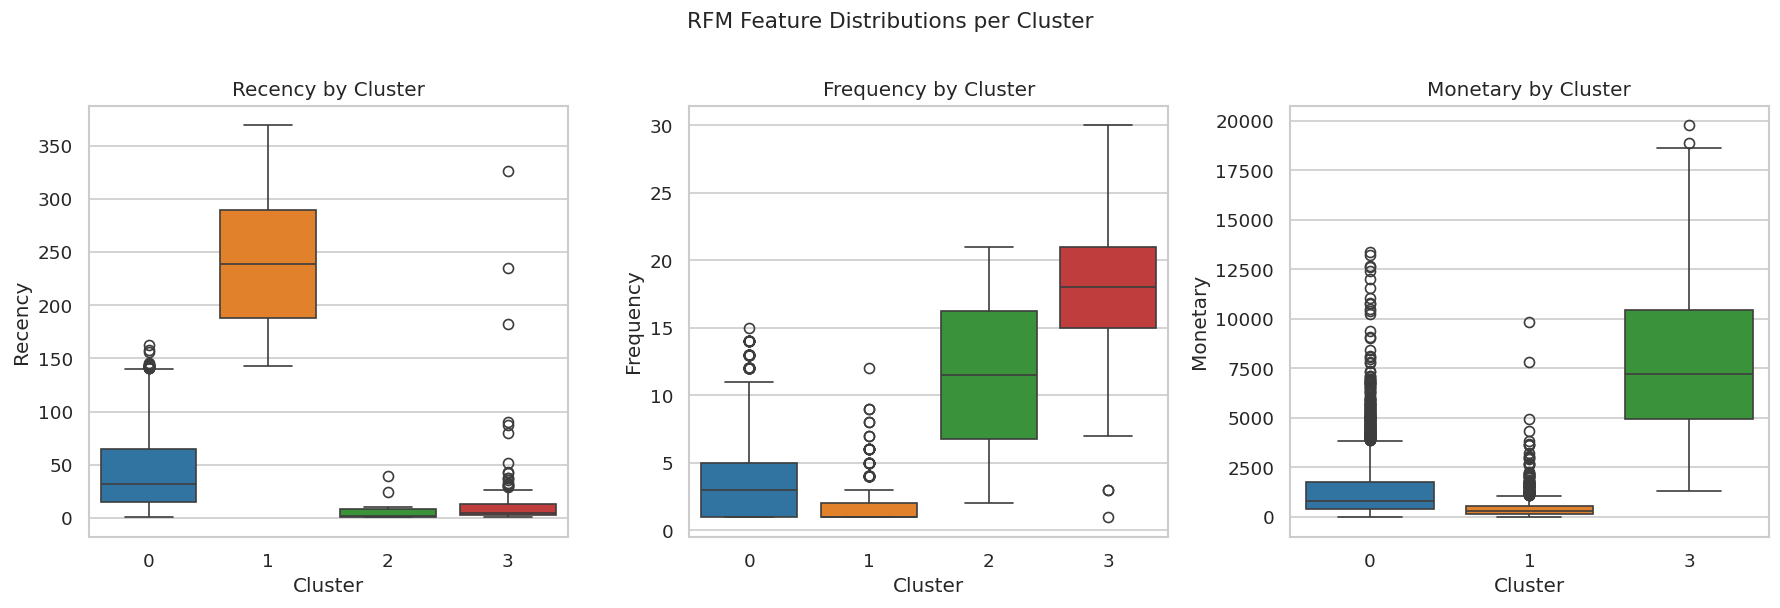

Saved → outputs/cluster_rfm_boxplots.png


In [21]:
# --- Box plots: RFM distributions per cluster ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, color in zip(axes, ['Recency', 'Frequency', 'Monetary'], ['#4C72B0', '#55A868', '#C44E52']):
    rfm_plot = rfm[rfm[col] <= rfm[col].quantile(0.99)]  # remove extreme outliers for display
    sns.boxplot(data=rfm_plot, x='Cluster', y=col, ax=ax, palette='tab10')
    ax.set_title(f'{col} by Cluster')
    ax.set_xlabel('Cluster')

plt.suptitle('RFM Feature Distributions per Cluster', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('outputs/cluster_rfm_boxplots.png', bbox_inches='tight')
plt.show()
print('Saved → outputs/cluster_rfm_boxplots.png')

---
## Section 10 — Cluster Interpretation

We compute per-cluster summary statistics to understand what each segment represents.  
After running this section, assign meaningful labels to each cluster in the cell below.

In [22]:
# --- Per-cluster mean RFM statistics ---
cluster_profiles = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].agg(
    ['mean', 'median', 'std', 'count']
).round(2)

cluster_profiles.columns = ['_'.join(col) for col in cluster_profiles.columns]
cluster_profiles = cluster_profiles.reset_index()

print('Cluster Profiles (mean / median / std / count):')
cluster_profiles

Cluster Profiles (mean / median / std / count):


,Cluster,Recency_mean,Recency_median,Recency_std,Recency_count,Frequency_mean,Frequency_median,Frequency_std,Frequency_count,Monetary_mean,Monetary_median,Monetary_std,Monetary_count
0,0,43.70,32.0,35.97,3054,3.68,3.0,2.86,3054,1353.63,826.27,1540.04,3054
1,1,248.08,243.0,66.33,1067,1.55,1.0,1.07,1067,478.85,310.26,637.70,1067
2,2,7.38,2.0,11.49,13,82.54,63.0,63.26,13,127187.96,117210.08,79842.36,13
3,3,15.50,5.0,40.92,204,22.33,19.0,11.68,204,12690.50,7990.20,13165.76,204


In [23]:
# --- Save cluster profiles ---
cluster_profiles.to_csv('outputs/cluster_profiles.csv', index=False)
print('Saved → outputs/cluster_profiles.csv')

Saved → outputs/cluster_profiles.csv


In [24]:
# ── Assign segment labels after reviewing cluster profiles above ────────────────
# Update these labels to reflect what you observe in your data.
# Example labels — replace with your actual interpretation:
CLUSTER_LABELS = {
    0: 'Segment A — [Your Label Here]',
    1: 'Segment B — [Your Label Here]',
    2: 'Segment C — [Your Label Here]',
    3: 'Segment D — [Your Label Here]',
}
# ───────────────────────────────────────────────────────────────────────────────

rfm['Segment'] = rfm['Cluster'].map(CLUSTER_LABELS)

print('Segment distribution:')
print(rfm['Segment'].value_counts())

Segment distribution:
Segment
Segment A — [Your Label Here]    3054
Segment B — [Your Label Here]    1067
Segment D — [Your Label Here]     204
Segment C — [Your Label Here]      13
Name: count, dtype: int64


## Section 11 — Business Insights & Recommendations

### 11.1 Segment-wise Analysis

#### Cluster 0 — Regular Customers

- **Profile:** Recency = 43.70 days, Frequency = 3.68 purchases, and Monetary = £1,353.63 on average.
- **Who they are:** This is the largest customer segment, containing 3,054 customers with relatively recent and regular purchasing behaviour.
- **Recommended strategy:** Maintain engagement through personalised product recommendations, loyalty incentives, and relevant promotional offers.

#### Cluster 1 — At-Risk / Inactive Customers

- **Profile:** Recency = 248.08 days, Frequency = 1.55 purchases, and Monetary = £478.85 on average.
- **Who they are:** These customers have not purchased recently and have relatively low purchase frequency and spending.
- **Recommended strategy:** Use re-engagement and win-back campaigns, personalised offers, and reminders to encourage another purchase.

#### Cluster 2 — VIP / Champion Customers

- **Profile:** Recency = 7.38 days, Frequency = 82.54 purchases, and Monetary = £127,187.96 on average.
- **Who they are:** A very small group of 13 customers with extremely high purchase frequency and monetary value.
- **Recommended strategy:** Provide VIP loyalty benefits, personalised service, exclusive offers, and retention-focused engagement.

#### Cluster 3 — High-Value Loyal Customers

- **Profile:** Recency = 15.50 days, Frequency = 22.33 purchases, and Monetary = £12,690.50 on average.
- **Who they are:** These 204 customers purchase frequently, have purchased recently, and generate substantially higher spending than the regular customer segment.
- **Recommended strategy:** Strengthen loyalty through rewards, personalised recommendations, cross-selling, and targeted promotions.

### 11.2 Overall Strategic Recommendations

1. **Retain high-value customers** — Maintain strong relationships with the VIP and high-value loyal segments through personalised engagement and loyalty benefits.

2. **Re-engage at-risk customers** — Use targeted win-back campaigns and relevant offers for customers with high recency and lower purchasing activity.

3. **Nurture regular customers** — Encourage the large regular-customer segment to increase purchase frequency and spending through personalised recommendations and loyalty incentives.

4. **Track segment migration** — Re-run the RFM analysis periodically to identify changes in customer purchasing behaviour and movement between segments.

5. **Personalise communications** — Use the identified customer segments to support targeted marketing and customer engagement strategies.

## Section 12 — Conclusion

### Summary of Findings

In this project, we applied K-Means Clustering to the Online Retail transaction dataset to segment customers based on their purchasing behaviour using Recency, Frequency, and Monetary (RFM) metrics.

- **Dataset:** The dataset contained 541,909 transaction records and 8 columns, covering transactions from December 2010 to December 2011. After cleaning and feature creation, the final dataset contained 392,692 valid transaction records across 9 columns.
- **Cleaning:** 5,268 duplicate records were removed, 135,037 records without CustomerID were removed, and 8,912 records with invalid quantity or unit price values were removed. The InvoiceDate column was also correctly parsed and TotalPrice was calculated.
- **RFM Analysis:** RFM features were calculated for 4,338 unique customers and standardized using StandardScaler.
- **Optimal k:** K-Means clustering with k = 4 was selected based on the Elbow Method and supported by a Silhouette Score of 0.6162.
- **Segments identified:**
  - **Cluster 0 — Regular Customers:** 3,054 customers with relatively recent and regular purchasing behaviour.
  - **Cluster 1 — At-Risk / Inactive Customers:** 1,067 customers with high recency and relatively low purchasing activity.
  - **Cluster 2 — VIP / Champion Customers:** 13 customers with extremely high purchase frequency and monetary value.
  - **Cluster 3 — High-Value Loyal Customers:** 204 customers with recent purchases, high frequency, and high monetary value.

### Objectives Achieved

| **Objective**                         | **Status**  |
| ------------------------------------- | ----------- |
| Data loading and quality check        | ✅ Completed |
| Data cleaning                         | ✅ Completed |
| Exploratory Data Analysis             | ✅ Completed |
| RFM feature engineering               | ✅ Completed |
| K-Means clustering with Elbow Method  | ✅ Completed |
| Cluster visualisation                 | ✅ Completed |
| Business insights and recommendations | ✅ Completed |

### Future Work

- Explore **DBSCAN** or **Hierarchical Clustering** for alternative customer segmentation approaches.
- Incorporate additional customer or transaction attributes to enrich segment profiles.
- Build a **churn prediction model** using the identified customer segments.
- Automate the analysis pipeline for periodic customer segmentation updates.

---

*End of Notebook — IBM SkillsBuild Data Analytics with AI Internship*